# Introduction to Workbench

Programming quantum computers requires a different set of concepts and operations than classical computers. **Workbench** is a Python package for developing algorithms for fault-tolerant quantum computers. This kata introduces the basics of writing quantum programs with Workbench.

## QPU

The QPU represents the quantum processing unit used to execute a Workbench program. It acts as the interface between your program and the quantum backend.  In particular, it manages:

* Allocating and releasing qubits
* Drawing circuit representation of the programs
* Supporting program testing and debugging by enabling direct access to the quantum simulator state
* Getting estimates of resources, such as number of qubits and number of magic states, necessary for running the program on a fault-tolerant quantum computer
* Processing and tracking low-level QPU events and instructions
* Configuring compilation pipelines

We will cover the basics of the first three roles of the QPU object in this notebook. To learn more about resource estimates and filters, check out the ["Introduction to quantum resource estimation" kata](../IntroToQRE/IntroToQRE.ipynb).

### QPU initialization

Typically, a QPU must be instantiated with a certain number of qubits. Otherwise, there will be no quantum resources to perform computation on. Below is a basic instantiation of a QPU by specifying the `num_qubits` argument in the constructor:

```python
qpu = QPU(num_qubits=3)
```

The `num_qubits` argument sets the upper limit of qubits available to the QPU. A program will not be able to allocate more qubits than have been specified at QPU instantiation.

You can learn more about the QPU in the [documentation on the QPU object](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/QPU-Object.html).

## Problem 1. Instantiate a QPU

**Input**:
An integer `num_qubits` representing the number of qubits the QPU should have.

**Goal**:
Instantiate and return a QPU object with a upper limit of qubits equal to `num_qubits`.

In [ ]:
from psiqdk.workbench import QPU
from test_IntroToWorkbench import problem

@problem
def instantiate_qpu(num_qubits: int):
    # Write your code here
    qpu = ...
    return qpu

## Allocating qubits

Now that we have defined a QPU that has an upper limit of qubits it can use, we can allocate **qubit registers** on that QPU.

A qubit register is allocated by creating an instance of the `Qubits` class. At instantiation, we pass the QPU that manages the allocation as the argument. We also pass the number of qubits and a string representing the name of the register as the arguments.

The following code snippet allocates two registers on a five-qubit QPU: `reg1` with three qubits and `reg2` with two qubits.

```python
qpu = QPU(num_qubits=5)           # Instantiate a QPU with 5 qubits

reg1 = Qubits(3, "reg1", qpu=qpu) # Allocate a qubit register named reg1 with 3 qubits
reg2 = Qubits(2, "reg2", qpu=qpu) # Allocate a qubit register named reg2 with 2 qubits
```

You can learn more about Qubits in the [documentation on Qubits data type](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Qubits-Data-Type.html).

## Problem 2. Instantiate a qubit register

**Inputs**:
1. A QPU object to manage allocation.
2. An integer `num_qubits` representing the number of qubits.
3. A string `name` representing the name of the register.

**Goal**:
Instantiate and return a Qubits object allocated on the qiven QPU, with the given number of qubits, with the given string as the name.

In [ ]:
from psiqdk.workbench import QPU, Qubits
from test_IntroToWorkbench import problem

@problem
def instantiate_qubits(qpu: QPU, num_qubits: int, name: str):
    # Write your code here
    qubits = ...
    return qubits

## Quantum gates

**Quantum gates** are the building blocks for performing quantum computation in Workbench programs.  These are operations that are applied to specific sets of qubits.

Gates are applied by calling various methods on `Qubits` objects.  Since each `Qubits` object is associated with a particular QPU, this adds the particular gates to the program for that QPU automatically.  When we call a method on a  `Qubits` object, the corresponding gate is applied to every individual qubit in that register.

Some gates require additional parameterization, such as rotation gates which require rotation angles.  These are provided as arguments to the gate method when needed.

The following code shows how to apply `x`, `y` and `z` gates to `Qubits` objects of various sizes to demonstrate the application of the gate to the entire register.  It also shows how to apply an `rx` gate with 37 degree rotation angle to `reg1`.

You can learn more about gates in the [documentation on basic gates](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Basic-Gates.html).

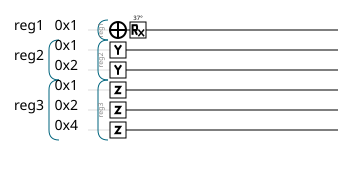

In [1]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=6)
reg1 = Qubits(1, "reg1", qpu=qpu)
reg2 = Qubits(2, "reg2", qpu=qpu)
reg3 = Qubits(3, "reg3", qpu=qpu)

reg1.x()
reg2.y()
reg3.z()

reg1.rx(37)

qpu.draw()

## Problem 3. Apply quantum gates

**Inputs**:
1. A `Qubits` register to apply gates to.
2. An integer `angle` - the value of the angle to use for rotations, in degrees.

**Goal**:
Apply an `x` gate to each qubit in the register using a single method call. Then, do the same for an `rx` gate with the given rotation angle.

In [ ]:
from psiqdk.workbench import Qubits
from test_IntroToWorkbench import problem

@problem
def apply_gates(reg: Qubits, angle: int):
    # Write your code here
    ...

## Controlled quantum gates

Single-qubit gates without any conditions are, of course, not enough to perform quantum computation.  We often need to apply a specific gate to one qubit register conditioned on whether another qubit register is in the $\ket{1}$ state. This is done through controlled gates.

In Workbench, all gate methods on qubits can be modified with the `cond` argument to turn them into controlled gates.  The `cond` argument accepts a `Qubits` register which acts as the control register for the gate. There is no specific modifier for the number of control qubits in the register.  The code below shows how to change the number of control qubits simply by passing registers of different sizes to `cond`.

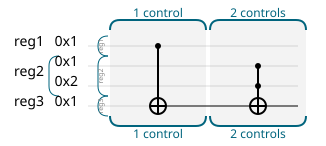

In [2]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=4)
reg1 = Qubits(1, "reg1", qpu=qpu)
reg2 = Qubits(2, "reg2", qpu=qpu)
reg3 = Qubits(1, "reg3", qpu=qpu)

qpu.label("1 control")
reg3.x(cond=reg1)
qpu.label("2 controls")
reg3.x(cond=reg2)

qpu.draw()

Generally, we are not limited to conditioning our gates on all qubits of the control register being in the $\ket{1}$ state. If we want to control a gate on the control register being in a particular state, we can simply check that the control register is equal to the corresponding value.

In the example below, each of the X gates is controlled on a two-qubit register `reg1` being in a different basis state. Workbench uses little-endian encoding for control patterns: conditioning on $1$ translates to applying the gate if the least significant bit of the register (the top wire) is in the $\ket{1}$ state and the most significant (the bottom wire) - in the $\ket{0}$ state. (Notice that conditioning on the register being in the $\ket{3}$ state is the same as simply passing that register as `cond`.)

You can learn more about controlled gates in the [documentation on controlled gates](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Controlled-Gates.html).

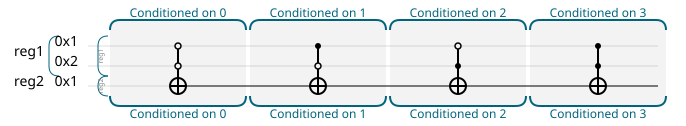

In [3]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3)
reg1 = Qubits(2, "reg1", qpu=qpu)
reg2 = Qubits(1, "reg2", qpu=qpu)

for i in range(4):
    qpu.label(f"Conditioned on {i}")
    reg2.x(cond=reg1 == i)

qpu.draw()

## Problem 4. Apply controlled quantum gates

**Inputs**:
1. A `Qubits` register `reg1`.
2. A `Qubits` register `reg2`.

**Goal**:

Apply three controlled `x` gates:
1. Apply `x` gate to register `reg2` controlled on each qubit of `reg1` being in the $\ket{1}$ state.
2. Apply `x` gate to register `reg2` controlled on each qubit of `reg1` being in the $\ket{0}$ state.
3. Apply `x` gate to register `reg1` controlled on each qubit of `reg2` being in the $\ket{1}$ state.

In [ ]:
from psiqdk.workbench import Qubits
from test_IntroToWorkbench import problem

@problem
def apply_controlled_gates(reg1: Qubits, reg2: Qubits):
    # Write your code here
    ...

## Drawing the circuit

As we build quantum programs, they can become difficult to debug. One method of debugging and verifying the construction of quantum programs is by visually inspecting the circuit they produce. Through the use of labels and boxes, this can help identify problems in quantum programs that might be difficult to find by observing the state vector or programmatic construction process alone.

The `QPU.draw()` method outputs the circuit to an SVG that can be displayed in a notebook.

QPU object provides some utility drawing methods:
- `nop()` adds blank padding operations.
- `label("name")` highlights a section of the circuit with label `"name"`.
- `label()` ends a previously started label.

You can learn more about the alternative methods of drawing circuits in the ["How to Draw a Circuit"](https://docs.construct.psiquantum.com/psiqdk-workbench/howtos/Draw-Circuit.html).

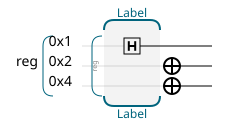

In [4]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3)
reg = Qubits(3, "reg", qpu=qpu)

# Start the label in the drawing
qpu.label("Label")

# Add some gates
reg[0].had()

# End the label
qpu.label()

# Add some unlabeled gates
reg[1:].x()

qpu.draw()

## Accessing particular qubits in a register

You don't always want to apply a gate to every qubit in a register; very often you want to apply a gate to just one qubit or use a subregister as a control for another gate. Workbench allows you to directly index and slice `Qubits` registers for that.

To access a particular qubit in a register, we can use indexing. The syntax is similar to accessing a particular element in an array in Python. Workbench, like Python, uses zero-based indexing for accessing qubits in a register.

```python
reg = Qubits(10, "reg", qpu)

reg[0]   # Access the first qubit in the register
reg[3]   # Access the fourth qubit in the register
reg[-1]  # Access the last qubit in the register
```

Also similar to Python arrays, we can use slicing to capture ranges of `Qubits`. If we have a `Qubits` register `reg`, we can access a range of qubits in it using `reg[start:stop:step]`. This produces a subarray of qubits in a new `Qubits` object beginning at index `start`, stopping at `stop-1`, and selecting the item at every index for which `(index - start) % step == 0`.

The following code snippet shows examples of different combinations of indexing and slicing arrays. Notice that we apply a gate directly the output of the indexing or slicing operation.  This is possible because each slice and index operation results in a new `Qubits` object that you can use in the same way as the initial instantiation.

You can learn more about accessing qubits in the [documentation on Qubits data type](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Qubits-Data-Type.html).

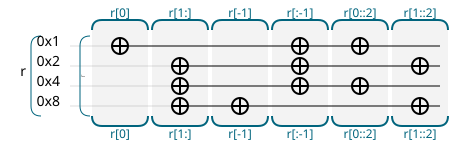

In [5]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=4)
r = Qubits(4, "r", qpu=qpu)

qpu.label("r[0]")     # First qubit
r[0].x()

qpu.label("r[1:]")    # All qubits except the first one
r[1:].x()

qpu.label("r[-1]")    # Last qubit
r[-1].x()

qpu.label("r[:-1]")   # All qubits except the last one
r[:-1].x()

qpu.label("r[0::2]")  # Even qubits
r[0::2].x()

qpu.label("r[1::2]")  # Odd qubits
r[1::2].x()

qpu.draw()

## Problem 5. Indexing and slicing

**Input**:
A `Qubits` register.

**Goal**:
Apply two different `x` gates to different ranges:
1. Apply an `x` gate to the second qubit in the register.
2. Apply an `x` gate to every even-indexed qubit except the qubit with index $0$ with a single operation.

You can assume that the `Qubits` register will always be large enough to satisfy these conditions.

In [ ]:
from psiqdk.workbench import Qubits
from test_IntroToWorkbench import problem

@problem
def indexing_and_slicing(reg: Qubits):
    # Write your code here
    ...

## Combining registers

Beyond the granularity of accessing individual qubits in a register, combining multiple registers can be useful. For instance, an algorithm can combine two registers to act as a single control register. As such, Workbench also provides a native operator to combine two registers.

By using the `|` or Bitwise-Or operator, we can concatenate two `Qubits` registers. The result is a single `Qubits` object that can be used the same way as the other `Qubits` objects. For example, the following code defines a two-qubit register `r3` as a concatenation of `r1` and `r2`.

```python
r1 = Qubits(1, "r1", qpu=qpu)
r2 = Qubits(1, "r2", qpu=qpu)
r3 = r1 | r2
```

The concatenatopn result can be directly passed to a `Qubits` constructor instead of the number of qubits in the register. This creates a named register that is a concatenation of the previously allocated ones instead of allocating a new register.

```python
r1 = Qubits(1, "r1", qpu=qpu)
r2 = Qubits(1, "r2", qpu=qpu)
r3 = Qubits(r1 | r2, "r3")
```

The following code shows both styles of concatenation by applying a gate to the resulting register. Notice that both methods produce the same result, but in the second case the register is named.

You can learn more about combining qubits in the [documentation on Qubits data type](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Qubits-Data-Type.html).

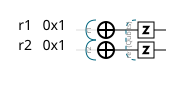

In [6]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=2)
r1 = Qubits(1, "r1", qpu=qpu)
r2 = Qubits(1, "r2", qpu=qpu)

concat = r1 | r2
concat.x()

ref = Qubits(r1 | r2, "ref")
ref.z()

qpu.draw()

## Problem 6. Combining registers

**Inputs**:
1. A `Qubits` register `reg1`.
2. A `Qubits` register `reg2`.
3. A `Qubits` register `reg3`.

**Goal**:

Apply three different gates to different combinations of gates:
1. Apply an `x` gate to the concatenation of the first and third registers.
2. Apply an `y` gate to the concatenation of the second and third registers.
3. Apply an `z` gate to the concatenation of the first, second and third registers.

Each gate should be applied via a single instruction.

In [ ]:
from psiqdk.workbench import Qubits
from test_IntroToWorkbench import problem

@problem
def concatenate_registers(reg1: Qubits, reg2: Qubits, reg3: Qubits):
    # Write your code here
    ...

## Getting state vector information

Workbench provides a variety of tools for running quantum programs on simulators and testing and debugging them. These tools take advantage of the fact that simulators are classical programs which allow you to directly observe the state vector during program simulattion. This is incredibly useful for debugging particular components of quantum programs.

There are two main ways we can access the state vector by using the QPU interface.

We can use the `print_state_vector()` method on a QPU to both print the list of non-zero amplitudes with corresponding basis states and to return the string representation of this list. This is useful to inspect the state for debugging.

Alternatively, we can use the `pull_state()` method to get the entire state vector as a list of complex amplitudes, zero and non-zero both. This is useful to observe the amplitudes programatically, in particular, when writing tests for Workbench programs.

The following example shows both these methods. The indices denoting the amplitudes correspond to the bitstring representation of the corresponding basis state in little-endian encoding.

You can learn more about using the state vector in the [documentation on testing and debugging](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Testing-Debugging.html).

In [7]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3)

reg1 = Qubits(2, "reg1", qpu)
reg2 = Qubits(1, "reg2", qpu)

reg1[0].ry(2 * 60)
reg1[1].ry(2 * 30, cond=reg1[0])
reg2.ry(-2 * 45)

print("Printed vector")
qpu.print_state_vector()

print("\nPulled state")
print(qpu.pull_state())

Printed vector
|reg1|reg2>
|0|0>    0.353553+0.000000j
|0|1>    -0.353553+0.000000j
|1|0>    0.530330+0.000000j
|1|1>    -0.530330+0.000000j
|3|0>    0.306186+0.000000j
|3|1>    -0.306186+0.000000j

Pulled state
[ 0.35355339+0.j  0.53033009+0.j  0.        +0.j  0.30618622+0.j
 -0.35355339+0.j -0.53033009+0.j  0.        +0.j -0.30618622+0.j]


## Problem 7. Using the state vector

**Input**:
A QPU object representing a program that reached a certain quantum state.

**Goal**:
Identify the basis states with the maximum amplitude (assume that all amplitudes are real values) and
return the result as a list of indices sorted in increasing order.

**Examples**:
- If the state vector was `[0.707, 0, 0, 0.707]`, the function should return `[0, 3]`.
- If the state vector was `[0, 0, 1, 0]`, the function should return `[2]`.

<details>
<summary><strong>Need a hint?</strong></summary>

To test whether two amplitudes are the same, you can use the `np.isclose` method.

To sort an array, you can use `sorted(array)`.
</details>

In [ ]:
import numpy as np
from psiqdk.workbench import QPU
from test_IntroToWorkbench import problem

@problem
def examine_state_vector(qpu: QPU) -> list[int]:
    # Write your code here
    ...

## Measuring qubits

Measurements in Workbench are implemented as the `read()` method of `Qubits` registers.

This method returns an integer representing the measurement result in little-endian encoding.  That is, the first qubit in the register corresponds to the least signifcant bit in the binary representation of the integer.

The code below shows several examples of measuring a register and printing the result.

You can learn more about measurements in the [documentation on measurements](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Measurements.html).

First measurement result:  2
Second measurement result:  1


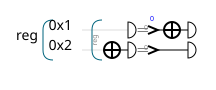

In [8]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=2)
reg = Qubits(2, "reg", qpu=qpu)
reg[1].x()         # Flip the most significant qubit
print("First measurement result: ", reg.read())

reg.write(0)       # Reset the register to |0⟩ state
reg[0].x()         # Flip the least significant qubit
print("Second measurement result: ", reg.read())

qpu.draw()

## Problem 8. Using measurements

**Input**:
A function you can run to get a four-qubit `Qubits` register. This function constructs and runs a circuit to allocate a register, prepare it in a fixed state, and return it. You can run this function by calling `func()`.

**Goal**:
Run the function and measure the returned `Qubits` object $1000$ times. Return a dictionary with a mapping of the different measurement results to the number of times each one was obtained.

In [ ]:
from typing import Callable
from psiqdk.workbench import Qubits
from test_IntroToWorkbench import problem

@problem
def use_measurements(func: Callable[[], Qubits]) -> dict[int, int]:
    result_dict = {}

    # Write your code here
    ...
    
    return result_dict

## Building Qubricks

Qubricks are quantum functions - a way to encapsulate sequences of quantum operations that provides utilities like automatic uncomputation and auxiliary qubit management. Qubricks allow for many instructions to be put in sequence and parametrized to organize components of larger algorithms. In this section, we will introduce the basic features of Qubricks.

A Qubrick is defined as a Python [class](https://docs.python.org/3/tutorial/classes.html). The only methods you have to implement are the `_compute` method and (optionally) the constructor `__init__`.

### The `_compute` method

The `_compute` method contains the core logic of performing the quantum routine defined by a Qubrick. 

For example, in the `BellPair` Qubrick below, the `_compute` method has one argument: the register on which it will prepare the Bell pair.  The body of this method has all the logic required to prepare the Bell pair.

You can use the `_compute` method without an implementation (by leaving its body empty) to provide the structure of the routine without detailing every gate. This can be useful when you're designing the high-level structure of your algorithm and want to treat the Qubrick as a "black box" for plotting a circuit diagram or running resource estimation.

### The constructor

While not always necessary, the constructor offers a way to provide high level details to the Qubrick. In the `BellPair` example, the Qubrick has an integer argument to denote which Bell pair it will construct.

### Helper methods

Since a Qubrick is just a Python class, you can define other helper methods and call them from the constructor and `_compute` methods.  Additionally, you can call the `compute` methods for other Qubricks to use subroutines required by the initial Qubrick.

You can learn more about Qubricks in the [documentation on Qubricks](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Qubricks.html).

In [9]:
from psiqdk.workbench import Qubits, Qubrick

class BellPair(Qubrick):
    def __init__(self, pair_kind: int=0, **kwargs):
        super().__init__(**kwargs)
        self.pair_kind = pair_kind

    def _compute(self, qubits: Qubits):
        if self.pair_kind % 2:
            qubits[0].x()
        if self.pair_kind // 2:
            qubits[1].x()
        qubits[0].had()
        qubits[1].x(qubits[0])

## Problem 9. Build a Qubrick

**Goal**: Write a Qubrick that constructs the GHZ circuit.

The `_compute` method should take one input: the `Qubits` register on which to construct the GHZ state.

> The GHZ circuit applies a Hadamard gate to the first qubit to put it in superposition, then entangles that qubit with every other qubit  using a controlled-X gate with that qubit as the target and the first qubit as the control.
>
> The resulting state is an equal superposition of the all $\ket{0}$ state and all $\ket{1}$ state; for example, for a three-qubit system it will be $0.707\ket{000} + 0.707\ket{111}$.

In [ ]:
from psiqdk.workbench import Qubits, Qubrick
from test_IntroToWorkbench import problem

@problem
class GHZ(Qubrick):
    def _compute(self, reg: Qubits):
        # Write your code here
        ...

## Applying Qubricks

There are two steps to apply the logic of a Qubrick to a circuit.

The first is to instantiate the Qubrick itself. For the Bell pair example Qubrick this would be:

```python
bell_pair = BellPair(pair_type=0)
```

This gives us an object to use. Now, we call its `compute` method (no underscore) with the relevant arguments.  This applies the gates in the body of the `_compute` method to the circuit.

```python
bell_pair.compute(control, target)
```

Notably, the Qubrick framework provides extra functionality, such as automatic uncomputation.  To apply it, we simply call the `uncompute` method.  This replays the previous call to `compute` in reverse, uncomputing the resulting circuit.

```python
bell_pair.uncompute()
```

The following example shows a full example of Qubrick appliciation, including constructors, computation and uncomputation.

In [ ]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=2)
reg = Qubits(2, "reg", qpu=qpu)

for ind in range(4):
    bell_pair = BellPair(ind)     # Instantiate the Qubrick

    bell_pair.compute(reg)
    print(f"Bell pair type {ind}:")
    qpu.print_state_vector()
    bell_pair.uncompute()
    print("After uncompute:")
    qpu.print_state_vector()

qpu.draw(show_qubricks=True)

## Problem 10. Apply a Qubrick

**Input**:
An integer $n$ representing the size of the qubit register.

**Goal**:
Build a quantum program that applies your GHZ Qubrick from the previous problem to an $n$-qubit register and return the QPU that stores this program.

In [ ]:
from psiqdk.workbench import QPU, Qubits
from test_IntroToWorkbench import problem

@problem
def apply_qubrick(n: int) -> QPU:
    qpu = QPU(num_qubits=n)
    reg = Qubits(n, "reg", qpu=qpu)
    
    # Write your code here
    ...

    return qpu

## Conclusion

Congratulations! In this kata, you have learned the basics of writing Workbench programs.

> Copyright (c) 2026 PsiQuantum